# Week 3: Feature Engineering and Model Building

## Telco Customer Churn Prediction

### Objective

The objective of Week 3 is to perform feature engineering and build predictive machine learning models using the Telco Customer Churn dataset.

The project focuses on creating meaningful customer-related features, preparing the data for machine learning, training classification models, evaluating their performance, and interpreting the results.

The target variable is **Churn**, which indicates whether a customer left the telecommunications service.

In [1]:
# Week 3: Feature Engineering and Model Building
# Telco Customer Churn Dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import io

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

# Folder for saved graphs
os.makedirs("week3_graphs", exist_ok=True)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
df = pd.read_csv('/content/Telco-Customer-Churn.csv')

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (7043, 21)


In [3]:
print("FIRST FIVE ROWS")
display(df.head())

print("\nDATASET INFORMATION")
df.info()

print("\nMISSING VALUES")
display(df.isnull().sum())

print("\nDUPLICATE ROWS")
print(df.duplicated().sum())

FIRST FIVE ROWS


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.8500,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.9500,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.8500,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.3000,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.7000,151.65,Yes



DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  704

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0



DUPLICATE ROWS
0


In [4]:
# Create a working copy
df_model = df.copy()

# Remove customerID because it is a unique identifier, not a useful predictive feature
df_model = df_model.drop(columns=["customerID"])

# Convert blank values in TotalCharges into missing values
df_model["TotalCharges"] = pd.to_numeric(
    df_model["TotalCharges"].replace(r"^\s*$", np.nan, regex=True),
    errors="coerce"
)

# Blank TotalCharges values occur for zero-tenure customers
df_model.loc[
    (df_model["tenure"] == 0) & (df_model["TotalCharges"].isna()),
    "TotalCharges"
] = 0

# If any unexpected missing values remain, use median imputation
df_model["TotalCharges"] = df_model["TotalCharges"].fillna(
    df_model["TotalCharges"].median()
)

# Convert target column to numeric
df_model["Churn"] = df_model["Churn"].map({
    "Yes": 1,
    "No": 0
})

print("Missing values:", df_model.isnull().sum().sum())
print("TotalCharges data type:", df_model["TotalCharges"].dtype)
print("\nChurn distribution:")
print(df_model["Churn"].value_counts())

Missing values: 0
TotalCharges data type: float64

Churn distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64


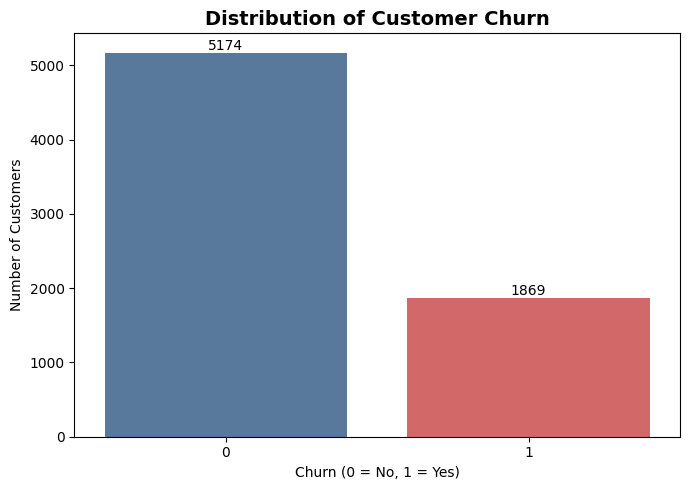

In [5]:
plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=df_model,
    x="Churn",
    hue="Churn",
    palette=["#4C78A8", "#E45756"],
    legend=False
)

plt.title("Distribution of Customer Churn", fontsize=14, fontweight="bold")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.savefig("week3_graphs/churn_distribution.png", dpi=300)
plt.show()

In [6]:
# 1. Total number of actual services used by each customer
service_columns = [
    "PhoneService",
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

df_model["TotalServices"] = (
    df_model[service_columns]
    .apply(lambda column: (column == "Yes").astype(int))
    .sum(axis=1)
)

# 2. Average amount charged per month
df_model["AvgMonthlySpend"] = np.where(
    df_model["tenure"] > 0,
    df_model["TotalCharges"] / df_model["tenure"],
    df_model["MonthlyCharges"]
)

# 3. Customer tenure groups
df_model["TenureGroup"] = pd.cut(
    df_model["tenure"],
    bins=[-1, 12, 36, 60, 72],
    labels=[
        "0-12 months",
        "13-36 months",
        "37-60 months",
        "61-72 months"
    ]
)

# 4. Customer has family support indicator
df_model["HasPartnerOrDependents"] = (
    (df_model["Partner"] == "Yes") |
    (df_model["Dependents"] == "Yes")
).astype(int)

# 5. Automatic payment indicator
df_model["AutoPayment"] = df_model["PaymentMethod"].isin([
    "Bank transfer (automatic)",
    "Credit card (automatic)"
]).astype(int)

# 6. Month-to-month contract indicator
df_model["IsMonthToMonth"] = (
    df_model["Contract"] == "Month-to-month"
).astype(int)

# 7. Cost per subscribed service
df_model["ChargePerService"] = (
    df_model["MonthlyCharges"] /
    df_model["TotalServices"].replace(0, 1)
)

print("Feature engineering completed successfully.")
display(df_model[
    [
        "tenure",
        "MonthlyCharges",
        "TotalCharges",
        "TotalServices",
        "AvgMonthlySpend",
        "TenureGroup",
        "AutoPayment",
        "IsMonthToMonth",
        "ChargePerService",
        "Churn"
    ]
].head())

Feature engineering completed successfully.


,tenure,MonthlyCharges,TotalCharges,TotalServices,AvgMonthlySpend,TenureGroup,AutoPayment,IsMonthToMonth,ChargePerService,Churn
0,1,29.8500,29.8500,1,29.8500,0-12 months,0,1,29.8500,0
1,34,56.9500,1889.5000,3,55.5735,13-36 months,0,0,18.9833,0
2,2,53.8500,108.1500,3,54.0750,0-12 months,0,1,17.9500,1
3,45,42.3000,1840.7500,3,40.9056,37-60 months,1,0,14.1000,0
4,2,70.7000,151.6500,1,75.8250,0-12 months,0,1,70.7000,1


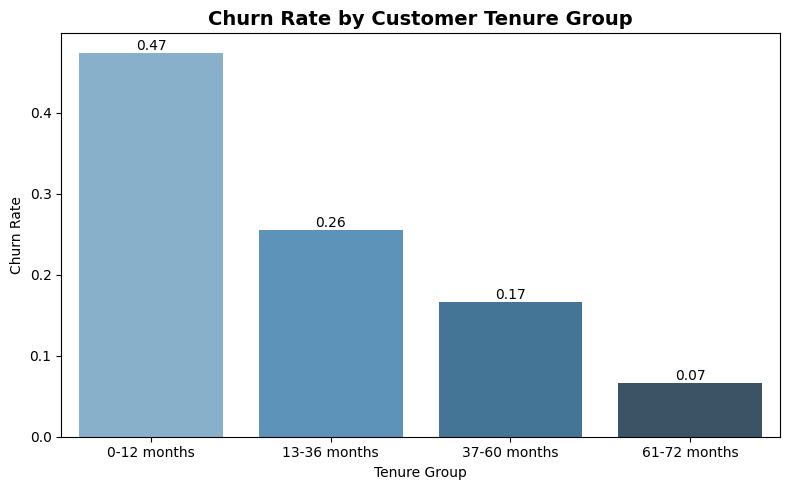

In [7]:
tenure_churn = (
    df_model.groupby("TenureGroup", observed=False)["Churn"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=tenure_churn,
    x="TenureGroup",
    y="Churn",
    hue="TenureGroup",
    palette="Blues_d",
    legend=False
)

plt.title("Churn Rate by Customer Tenure Group", fontsize=14, fontweight="bold")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.tight_layout()
plt.savefig("week3_graphs/churn_by_tenure_group.png", dpi=300)
plt.show()

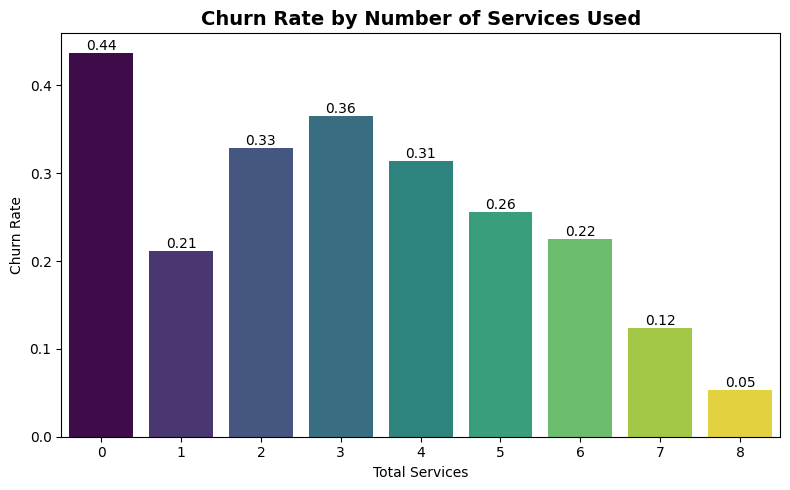

In [8]:
services_churn = (
    df_model.groupby("TotalServices")["Churn"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=services_churn,
    x="TotalServices",
    y="Churn",
    hue="TotalServices",
    palette="viridis",
    legend=False
)

plt.title("Churn Rate by Number of Services Used", fontsize=14, fontweight="bold")
plt.xlabel("Total Services")
plt.ylabel("Churn Rate")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.tight_layout()
plt.savefig("week3_graphs/churn_by_total_services.png", dpi=300)
plt.show()

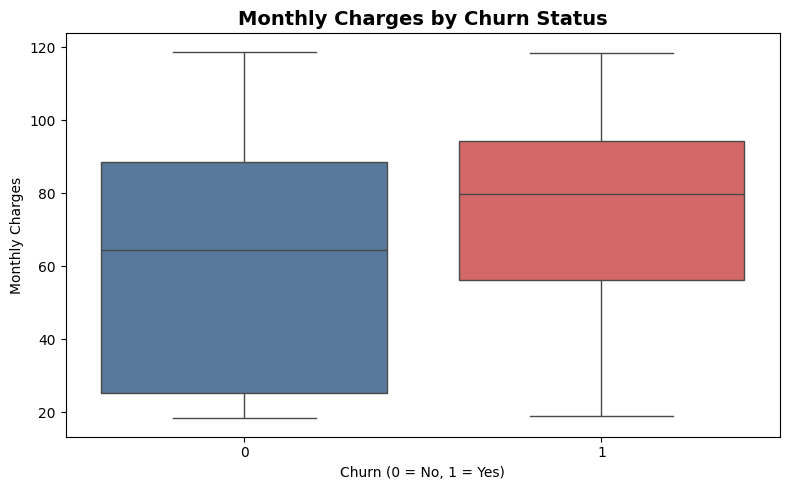

In [9]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_model,
    x="Churn",
    y="MonthlyCharges",
    hue="Churn",
    palette=["#4C78A8", "#E45756"],
    legend=False
)

plt.title("Monthly Charges by Churn Status", fontsize=14, fontweight="bold")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Monthly Charges")

plt.tight_layout()
plt.savefig("week3_graphs/monthly_charges_by_churn.png", dpi=300)
plt.show()

Model development

In [10]:
# Separate predictor variables and target variable
X = df_model.drop(columns=["Churn"])
y = df_model["Churn"]

# Split data: 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Identify numerical and categorical columns
numerical_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)
print("Numerical features:", len(numerical_features))
print("Categorical features:", len(categorical_features))

# Preprocessing for numerical columns
numerical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", MinMaxScaler())
])

# Preprocessing for categorical columns
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Combine preprocessing steps
preprocessor = ColumnTransformer(transformers=[
    ("num", numerical_transformer, numerical_features),
    ("cat", categorical_transformer, categorical_features)
])

Training data shape: (5634, 26)
Testing data shape: (1409, 26)
Numerical features: 10
Categorical features: 16


In [11]:
logistic_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

logistic_model.fit(X_train, y_train)

logistic_predictions = logistic_model.predict(X_test)
logistic_probabilities = logistic_model.predict_proba(X_test)[:, 1]

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [12]:
logistic_accuracy = accuracy_score(y_test, logistic_predictions)
logistic_precision = precision_score(y_test, logistic_predictions)
logistic_recall = recall_score(y_test, logistic_predictions)
logistic_f1 = f1_score(y_test, logistic_predictions)
logistic_auc = roc_auc_score(y_test, logistic_probabilities)

print("LOGISTIC REGRESSION PERFORMANCE")
print("-" * 40)
print(f"Accuracy:  {logistic_accuracy:.4f}")
print(f"Precision: {logistic_precision:.4f}")
print(f"Recall:    {logistic_recall:.4f}")
print(f"F1-score:  {logistic_f1:.4f}")
print(f"ROC-AUC:   {logistic_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, logistic_predictions))

LOGISTIC REGRESSION PERFORMANCE
----------------------------------------
Accuracy:  0.7991
Precision: 0.6502
Recall:    0.5267
F1-score:  0.5820
ROC-AUC:   0.8412

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.65      0.53      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



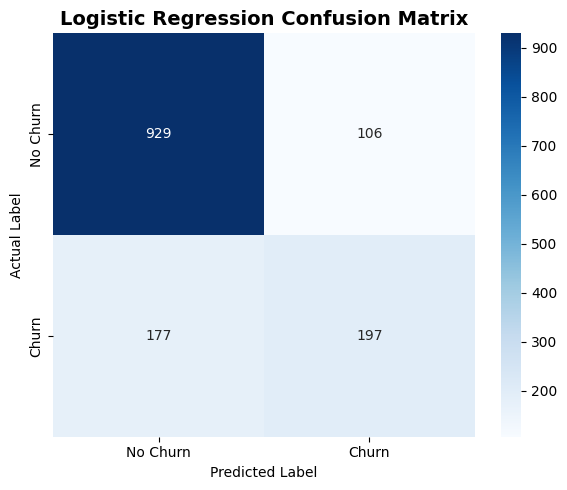

In [13]:
logistic_cm = confusion_matrix(y_test, logistic_predictions)

plt.figure(figsize=(6, 5))

sns.heatmap(
    logistic_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("Logistic Regression Confusion Matrix", fontsize=14, fontweight="bold")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.tight_layout()
plt.savefig("week3_graphs/logistic_confusion_matrix.png", dpi=300)
plt.show()

In [14]:
decision_tree_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(
        max_depth=5,
        min_samples_split=20,
        min_samples_leaf=10,
        random_state=42,
        class_weight="balanced"
    ))
])

decision_tree_model.fit(X_train, y_train)

tree_predictions = decision_tree_model.predict(X_test)
tree_probabilities = decision_tree_model.predict_proba(X_test)[:, 1]

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


In [15]:
tree_accuracy = accuracy_score(y_test, tree_predictions)
tree_precision = precision_score(y_test, tree_predictions)
tree_recall = recall_score(y_test, tree_predictions)
tree_f1 = f1_score(y_test, tree_predictions)
tree_auc = roc_auc_score(y_test, tree_probabilities)

print("DECISION TREE PERFORMANCE")
print("-" * 40)
print(f"Accuracy:  {tree_accuracy:.4f}")
print(f"Precision: {tree_precision:.4f}")
print(f"Recall:    {tree_recall:.4f}")
print(f"F1-score:  {tree_f1:.4f}")
print(f"ROC-AUC:   {tree_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, tree_predictions))

DECISION TREE PERFORMANCE
----------------------------------------
Accuracy:  0.7516
Precision: 0.5220
Recall:    0.7620
F1-score:  0.6196
ROC-AUC:   0.8353

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.75      0.82      1035
           1       0.52      0.76      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.80      0.75      0.76      1409



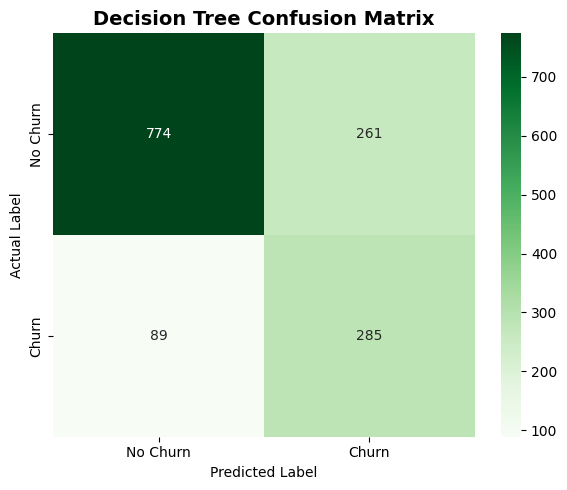

In [16]:
tree_cm = confusion_matrix(y_test, tree_predictions)

plt.figure(figsize=(6, 5))

sns.heatmap(
    tree_cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("Decision Tree Confusion Matrix", fontsize=14, fontweight="bold")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.tight_layout()
plt.savefig("week3_graphs/decision_tree_confusion_matrix.png", dpi=300)
plt.show()

In [17]:
model_results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree"],
    "Accuracy": [logistic_accuracy, tree_accuracy],
    "Precision": [logistic_precision, tree_precision],
    "Recall": [logistic_recall, tree_recall],
    "F1-Score": [logistic_f1, tree_f1],
    "ROC-AUC": [logistic_auc, tree_auc]
})

display(model_results.sort_values(by="ROC-AUC", ascending=False))

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.7991,0.6502,0.5267,0.5820,0.8412
1,Decision Tree,0.7516,0.5220,0.7620,0.6196,0.8353


## Model Evaluation and Comparison

Two classification models were developed and evaluated: Logistic Regression and Decision Tree Classifier.

### Logistic Regression Results

The Logistic Regression model achieved an accuracy of 79.91%, precision of 65.02%, recall of 52.67%, F1-score of 58.20%, and ROC-AUC score of 84.12%.

The model showed strong performance in predicting customers who did not churn. However, its recall for churned customers was 52.67%, meaning that it identified only around half of the actual churn cases. This is a limitation because the main objective of churn prediction is to identify customers who may leave the company.

### Decision Tree Results

The Decision Tree model achieved an accuracy of 75.16%, precision of 52.20%, recall of 76.20%, F1-score of 61.96%, and ROC-AUC score of 83.53%.

Although its accuracy and precision were lower than Logistic Regression, the Decision Tree achieved much higher recall. It correctly identified approximately 76 out of every 100 customers who churned. This makes the model more useful for a churn-retention strategy because it reduces the number of high-risk customers who are missed.

### Model Selection

Logistic Regression achieved the highest accuracy and ROC-AUC score. However, the Decision Tree achieved higher recall and F1-score for the churn class.

For this project, the Decision Tree is selected as the more suitable model for churn prediction because identifying potential churn customers is more important than maximizing overall accuracy. The model can help the company target customers who may leave with retention offers, better service support, or contract-based incentives.

<Figure size 800x600 with 0 Axes>

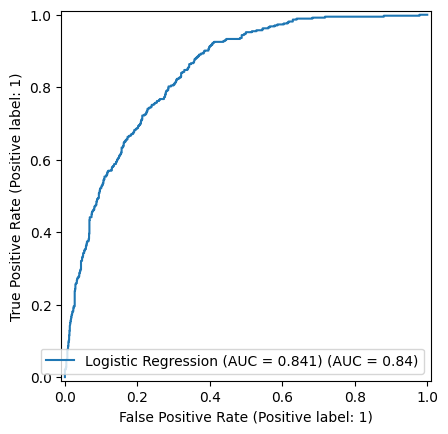

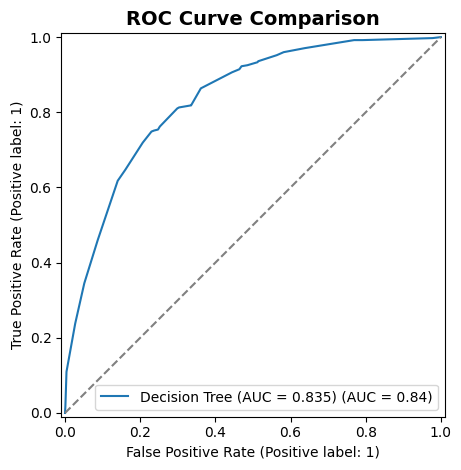

In [18]:
plt.figure(figsize=(8, 6))

RocCurveDisplay.from_predictions(
    y_test,
    logistic_probabilities,
    name=f"Logistic Regression (AUC = {logistic_auc:.3f})"
)

RocCurveDisplay.from_predictions(
    y_test,
    tree_probabilities,
    name=f"Decision Tree (AUC = {tree_auc:.3f})"
)

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.title("ROC Curve Comparison", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.savefig("week3_graphs/roc_curve_comparison.png", dpi=300)
plt.show()

,Feature,Importance
8,IsMonthToMonth,0.6049
1,tenure,0.1167
22,InternetService_Fiber optic,0.1074
2,MonthlyCharges,0.0365
3,TotalCharges,0.0210
33,TechSupport_No,0.0193
5,AvgMonthlySpend,0.0189
44,Contract_Two year,0.0170
24,OnlineSecurity_No,0.0126
17,PhoneService_Yes,0.0116


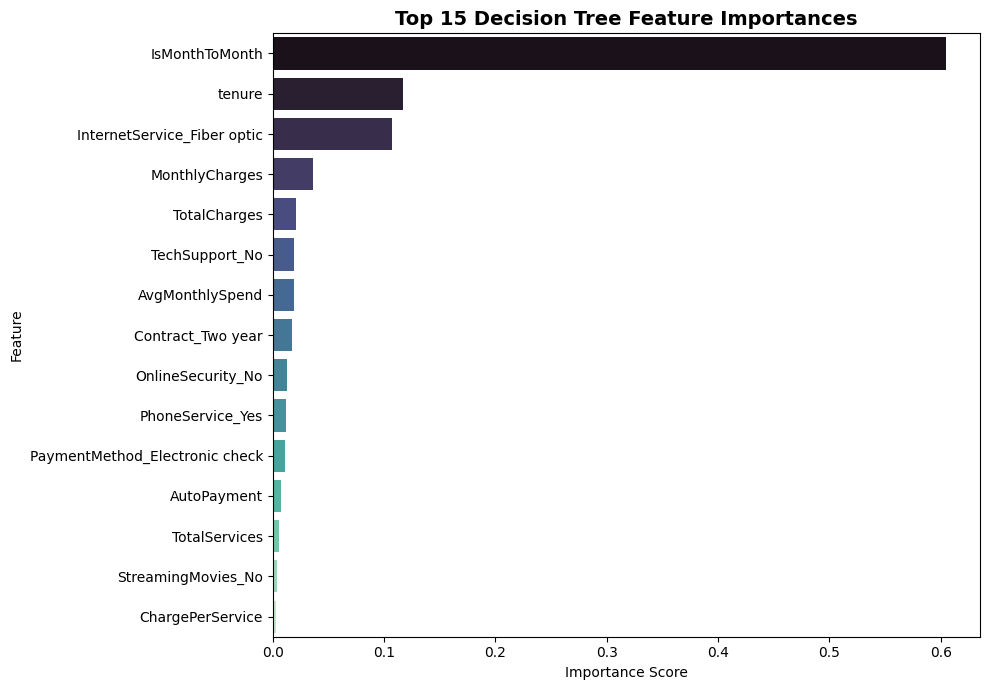

In [19]:
feature_names = decision_tree_model.named_steps[
    "preprocessor"
].get_feature_names_out()

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": decision_tree_model.named_steps[
        "model"
    ].feature_importances_
})

feature_importance["Feature"] = (
    feature_importance["Feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

top_features = feature_importance.sort_values(
    by="Importance",
    ascending=False
).head(15)

display(top_features)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="mako",
    legend=False
)

plt.title(
    "Top 15 Decision Tree Feature Importances",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.tight_layout()
plt.savefig("week3_graphs/feature_importance.png", dpi=300)
plt.show()

## Feature Importance Interpretation

The Decision Tree feature-importance analysis showed that IsMonthToMonth was the most important feature, with an importance score of 0.6049. This indicates that whether a customer has a month-to-month contract was highly useful for predicting churn.

Tenure was the second most important feature, with an importance score of 0.1167. This suggests that the length of a customer's relationship with the company is strongly related to churn behaviour.

InternetService_Fiber optic was also important, with an importance score of 0.1074. MonthlyCharges, TotalCharges, lack of technical support, average monthly spending, contract type, online security, and payment method also contributed to the prediction process.

Feature importance indicates how useful a feature was for the Decision Tree model. It does not independently prove that the feature causes churn. Therefore, these findings should be interpreted as predictive patterns in the given dataset rather than direct causal relationships.

## Conclusion

This Week 3 project applied feature engineering and machine learning classification to predict customer churn. New features such as TotalServices, AvgMonthlySpend, TenureGroup, AutoPayment, IsMonthToMonth, and ChargePerService were created to represent customer behaviour more effectively.

Two classification models were trained and evaluated: Logistic Regression and Decision Tree Classifier. Their performance was compared using accuracy, precision, recall, F1-score, ROC-AUC, confusion matrices, ROC curves, and feature importance.

The final model selection should consider the balance between correctly identifying churn-risk customers and avoiding unnecessary false-positive predictions. Future improvements may include hyperparameter tuning, Random Forest, XGBoost, class-imbalance techniques, and cross-validation.